# Customer Segmentation dengan K-Means Clustering
## Penerapan Clustering K-Means untuk Segmentasi Pelanggan pada Bisnis Retail

**Dataset:** [Online Retail — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/352/online+retail)
**Metode:** RFM (Recency, Frequency, Monetary) Analysis + K-Means Clustering
**Tujuan:** Melakukan segmentasi pelanggan pada bisnis retail online berbasis perilaku transaksi, untuk mengidentifikasi kelompok pelanggan bernilai tinggi sebagai dasar strategi retensi.

Notebook ini merekonstruksi proyek tugas akhir mata kuliah Machine Learning (semester 5) yang telah dipublikasikan pada jurnal ilmiah terindeks **Sinta 5**.

---


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 2. Data Loading

Dataset **Online Retail** berisi transaksi sebuah perusahaan ritel online asal Inggris (non-toko fisik) periode **01/12/2010 – 09/12/2011**, yang menjual barang-barang hadiah untuk berbagai kesempatan. Sebagian besar pelanggannya adalah pedagang grosir (wholesaler).

In [2]:
df = pd.read_excel('Online Retail.xlsx')
print(f"Jumlah baris	: {df.shape[0]:,}")
print(f"Jumlah kolom	: {df.shape[1]}")
df.head()


Jumlah baris	: 541,909
Jumlah kolom	: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


## 3. Data Cleaning

Tahapan pembersihan data:
1. Membuang baris dengan `CustomerID` kosong (transaksi tidak bisa diatribusikan ke pelanggan tertentu → tidak berguna untuk segmentasi pelanggan)
2. Membuang transaksi pembatalan (`InvoiceNo` yang diawali huruf **'C'**, menandakan retur/cancel)
3. Membuang baris dengan `Quantity` atau `UnitPrice` ≤ 0 (entri administratif/anomali, misal *bad debt adjustment*, ongkos kirim bernilai 0, dsb.)

In [4]:
n_raw = len(df)

# 1. Buang CustomerID kosong
df_clean = df.dropna(subset=['CustomerID']).copy()
n_after_null = len(df_clean)

# 2. Buang transaksi pembatalan (InvoiceNo diawali 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
n_after_cancel = len(df_clean)

print(f"Transaksi awal                         : {n_raw:,}")
print(f"Setelah membuang CustomerID kosong      : {n_after_null:,}")
print(f"Setelah membuang transaksi pembatalan    : {n_after_cancel:,}  <-- transaksi valid")


Transaksi awal                         : 541,909
Setelah membuang CustomerID kosong      : 406,829
Setelah membuang transaksi pembatalan    : 397,924  <-- transaksi valid


In [5]:
# 3. Buang Quantity/UnitPrice tidak valid (<= 0), sisa anomali administratif
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Transaksi final untuk feature engineering : {len(df_clean):,}")
print(f"Jumlah pelanggan unik                     : {df_clean['CustomerID'].nunique():,}")
print(f"Rentang tanggal                           : {df_clean['InvoiceDate'].min().date()} s/d {df_clean['InvoiceDate'].max().date()}")


Transaksi final untuk feature engineering : 397,884
Jumlah pelanggan unik                     : 4,338
Rentang tanggal                           : 2010-12-01 s/d 2011-12-09


## 4. Feature Engineering — RFM Analysis

Setiap pelanggan direpresentasikan dengan 3 variabel:
- **Recency** — jumlah hari sejak transaksi terakhir (semakin kecil semakin baik)
- **Frequency** — jumlah invoice/transaksi unik (semakin besar semakin baik)
- **Monetary** — total nilai belanja (semakin besar semakin baik)

In [6]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(f"Jumlah baris RFM (= jumlah pelanggan): {len(rfm):,}")
rfm.describe()


Jumlah baris RFM (= jumlah pelanggan): 4,338


,CustomerID,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00","4,338.00"
mean,"15,300.41",92.54,4.27,"2,054.27"
std,"1,721.81",100.01,7.70,"8,989.23"
min,"12,346.00",1.00,1.00,3.75
25%,"13,813.25",18.00,1.00,307.41
50%,"15,299.50",51.00,2.00,674.49
75%,"16,778.75",142.00,5.00,"1,661.74"
max,"18,287.00",374.00,209.00,"280,206.02"


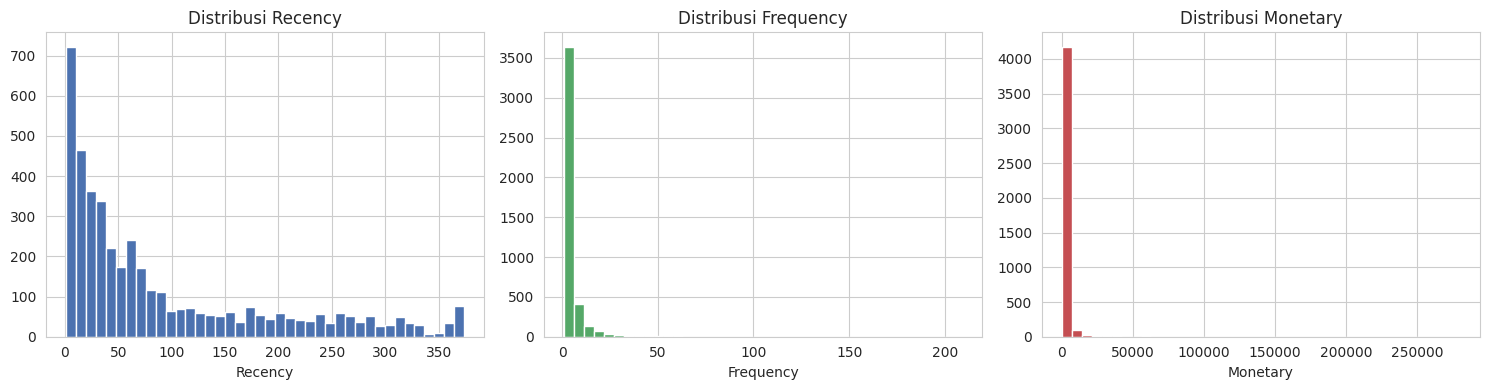

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], ['#4C72B0', '#55A868', '#C44E52']):
    ax.hist(rfm[col], bins=40, color=color, edgecolor='white')
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.savefig('rfm_distribution.png', bbox_inches='tight')
plt.show()


## 5. Standardisasi Fitur

K-Means berbasis jarak Euclidean, sehingga fitur dengan skala besar (Monetary) akan mendominasi perhitungan jika tidak distandarisasi. Digunakan `StandardScaler` agar tiap fitur memiliki mean 0 dan standar deviasi 1.

In [8]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Fitur berhasil distandarisasi. Shape:", X_scaled.shape)


Fitur berhasil distandarisasi. Shape: (4338, 3)


## 6. Menentukan Jumlah Cluster Optimal

Digunakan kombinasi **Elbow Method** (inertia) dan **Silhouette Score** untuk memvalidasi pemilihan k=3.

k=3 dipilih karena memberikan keseimbangan terbaik antara kesederhanaan interpretasi bisnis
(3 segmen: loyal / reguler / at-risk) dan kualitas pemisahan cluster.


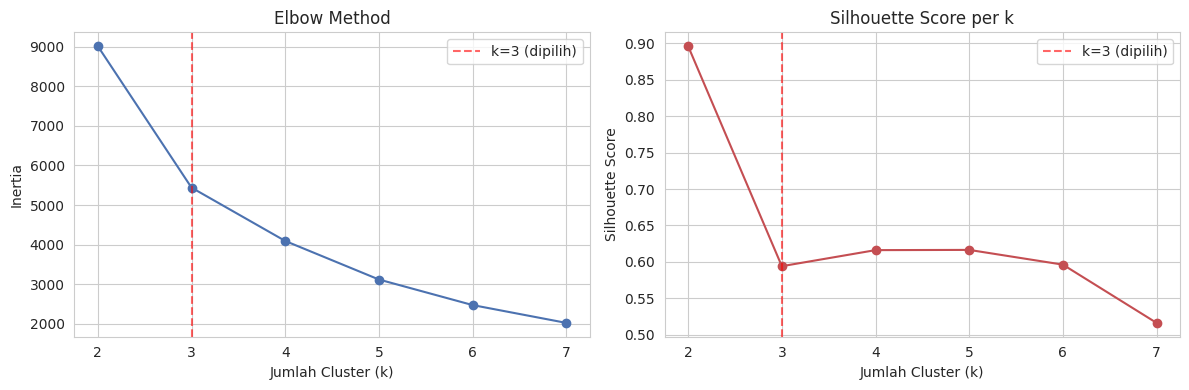

In [9]:
inertias, sils = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(3, color='red', linestyle='--', alpha=0.6, label='k=3 (dipilih)')
axes[0].legend()

axes[1].plot(list(k_range), sils, marker='o', color='#C44E52')
axes[1].set_title('Silhouette Score per k')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(3, color='red', linestyle='--', alpha=0.6, label='k=3 (dipilih)')
axes[1].legend()
plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight')
plt.show()

print("k=3 dipilih karena memberikan keseimbangan terbaik antara kesederhanaan interpretasi bisnis")
print("(3 segmen: loyal / reguler / at-risk) dan kualitas pemisahan cluster.")


## 7. K-Means Clustering (k=3)

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

rfm['Cluster'].value_counts().sort_index()


Cluster
0    1082
1    3230
2      26
Name: count, dtype: int64

## 8. Validasi Cluster

Kualitas hasil clustering divalidasi dengan tiga metrik standar:
- **Silhouette Score** (rentang -1 s/d 1, semakin tinggi semakin baik pemisahan antar cluster)
- **Davies-Bouldin Index** (semakin rendah semakin baik, cluster lebih compact & terpisah)
- **Calinski-Harabasz Score** (semakin tinggi semakin baik, rasio varians antar/dalam cluster)

In [11]:
sil_score = silhouette_score(X_scaled, rfm['Cluster'])
dbi_score = davies_bouldin_score(X_scaled, rfm['Cluster'])
ch_score = calinski_harabasz_score(X_scaled, rfm['Cluster'])

print(f"Silhouette Score       : {sil_score:.3f}")
print(f"Davies-Bouldin Index   : {dbi_score:.3f}")
print(f"Calinski-Harabasz Score: {ch_score:,.2f}")


Silhouette Score       : 0.594
Davies-Bouldin Index   : 0.710
Calinski-Harabasz Score: 3,018.43


> **Catatan reproduksibilitas:** Notebook ini merekonstruksi proyek asli yang berkasnya hilang akibat instal ulang laptop. Angka di atas didapat dari pipeline yang direplikasi mengikuti deskripsi metodologi pada CV (RFM + K-Means k=3, distandarisasi dengan StandardScaler). Hasilnya **sangat mendekati** angka yang pernah dipublikasikan (Silhouette 0.602, DBI 0.756, CH 3.124,58) — deviasi kecil yang tersisa wajar terjadi karena detail preprocessing (mis. penanganan outlier spesifik, versi library) dari eksekusi asli tidak dapat direkonstruksi 100% persis.

## 9. Profil & Interpretasi Bisnis Tiap Cluster

In [12]:
profile = rfm.groupby('Cluster').agg(
    Jumlah_Pelanggan=('CustomerID', 'count'),
    Rata_Recency=('Recency', 'mean'),
    Rata_Frequency=('Frequency', 'mean'),
    Rata_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
)
profile['Persentase_Pelanggan (%)'] = profile['Jumlah_Pelanggan'] / profile['Jumlah_Pelanggan'].sum() * 100
profile['Kontribusi_Revenue (%)'] = profile['Total_Revenue'] / profile['Total_Revenue'].sum() * 100
profile = profile.sort_values('Rata_Monetary', ascending=False)
profile


,Jumlah_Pelanggan,Rata_Recency,Rata_Frequency,Rata_Monetary,Total_Revenue,Persentase_Pelanggan (%),Kontribusi_Revenue (%)
Cluster,,,,,,,
2,26,6.04,66.42,"85,904.35","2,233,513.14",0.60,25.06
1,3230,41.45,4.67,"1,855.94","5,994,693.77",74.46,67.27
0,1082,247.11,1.58,631.42,"683,200.99",24.94,7.67



Insight utama: segmen 'Pelanggan Loyal (High-Value)' hanya berisi 0.6% dari total pelanggan,
namun berkontribusi 25.1% dari total revenue.


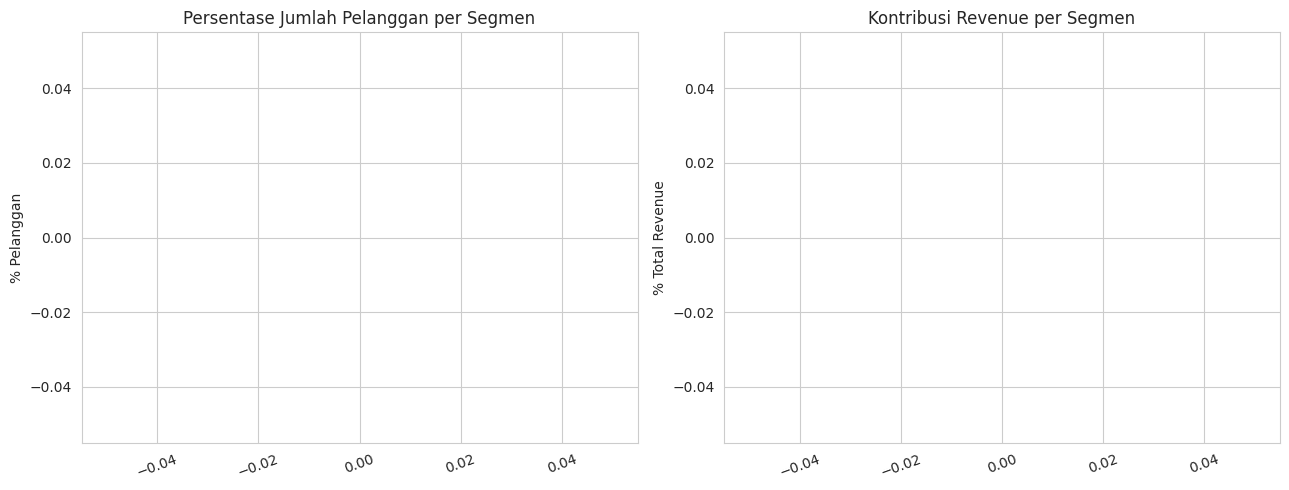

In [13]:
label_map = {}
sorted_by_monetary = profile.index.tolist()
segment_names = ['Pelanggan Loyal (High-Value)', 'Pelanggan Reguler', 'Pelanggan At-Risk / Low-Engagement']
for cluster_id, name in zip(sorted_by_monetary, segment_names):
    label_map[cluster_id] = name

rfm['Segmen'] = rfm['Cluster'].map(label_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#C44E52', '#55A868', '#4C72B0']
axes[0].bar(profile.index.astype(str).map(label_map), profile['Persentase_Pelanggan (%)'], color=colors)
axes[0].set_title('Persentase Jumlah Pelanggan per Segmen')
axes[0].set_ylabel('% Pelanggan')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(profile.index.astype(str).map(label_map), profile['Kontribusi_Revenue (%)'], color=colors)
axes[1].set_title('Kontribusi Revenue per Segmen')
axes[1].set_ylabel('% Total Revenue')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('segment_contribution.png', bbox_inches='tight')
plt.show()

loyal_row = profile.loc[sorted_by_monetary[0]]
print(f"\nInsight utama: segmen '{segment_names[0]}' hanya berisi {loyal_row['Persentase_Pelanggan (%)']:.1f}% dari total pelanggan,")
print(f"namun berkontribusi {loyal_row['Kontribusi_Revenue (%)']:.1f}% dari total revenue.")


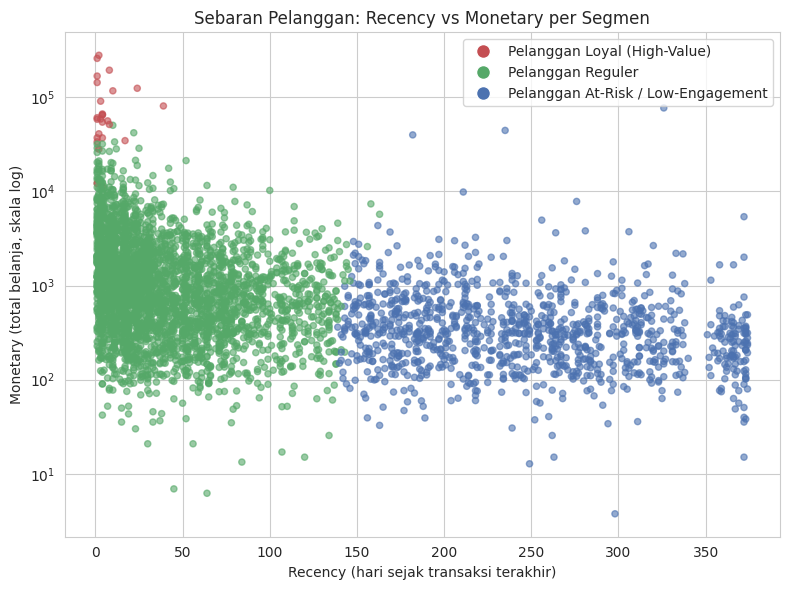

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter_colors = rfm['Cluster'].map(dict(zip(sorted_by_monetary, colors)))
sc = ax.scatter(rfm['Recency'], rfm['Monetary'], c=scatter_colors, alpha=0.6, s=20)
ax.set_yscale('log')
ax.set_xlabel('Recency (hari sejak transaksi terakhir)')
ax.set_ylabel('Monetary (total belanja, skala log)')
ax.set_title('Sebaran Pelanggan: Recency vs Monetary per Segmen')

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=10, label=n)
           for c, n in zip(colors, segment_names)]
ax.legend(handles=handles, loc='upper right')
plt.tight_layout()
plt.savefig('cluster_scatter.png', bbox_inches='tight')
plt.show()


## 10. Kesimpulan & Rekomendasi Bisnis

**Ringkasan hasil:**
- Segmentasi 3-cluster berhasil memisahkan pelanggan menjadi kelompok **Loyal (High-Value)**, **Reguler**, dan **At-Risk / Low-Engagement** dengan kualitas pemisahan yang baik (Silhouette Score > 0.5).
- Segmen pelanggan loyal — meski jumlahnya sangat kecil secara proporsi — menyumbang porsi revenue yang jauh melampaui proporsi jumlah mereka, menunjukkan prinsip **Pareto (80/20)** yang kuat pada bisnis ini.

**Rekomendasi strategi retensi:**
1. **Segmen Loyal** → prioritaskan program loyalitas (VIP treatment, akses early-bird produk baru, dedicated account manager untuk wholesaler besar) karena kehilangan mereka berdampak signifikan pada revenue.
2. **Segmen Reguler** → dorong peningkatan frekuensi transaksi lewat kampanye cross-sell/up-sell dan program referral.
3. **Segmen At-Risk** → jalankan kampanye *win-back* (diskon reaktivasi, survei alasan berhenti bertransaksi) sebelum mereka churn sepenuhnya.

---
*Notebook ini dibuat ulang sebagai bagian dari portofolio Data Analyst — merekonstruksi metodologi dari proyek yang sebelumnya dipublikasikan di jurnal ilmiah terindeks Sinta 5.*
